In [ ]:
from sklearn.model_selection import cross_val_score, KFold, cross_validate, RepeatedKFold
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFECV, RFE
from sklearn.linear_model import LinearRegression


from ml_enhance import plot_scaled_linreg_result, CorrelationFilter


import matplotlib.pyplot as plt
from sklearn import pipeline
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import json

In [2]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.95)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", StandardScaler()),
        (step_name, model)
    ])

In [3]:
pl_linear = make_pipeline(LinearRegression(), "predict")

In [4]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm.csv")

In [6]:
# df = df.drop("avg_atomic_quadrupole_principal_invariant_3", axis=1)
# df = df.drop("min_atomic_quadrupole_principal_invariant_3", axis=1)
# df = df.drop("max_atomic_quadrupole_principal_invariant_3", axis=1)
# df = df.drop("min_overlap_integral", axis=1)



# df = df.drop([1825, 587, 8657, 8169, 8655, 8654])
# df = df.drop(df[df["smiles"] == '[O:1]=[Si:2]=[O:3]'].index)
# df = df.drop(df[df['smiles'] == '[I:1][I:2]'].index)

y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [7]:
X.columns.to_list()

['atomization_energy',
 'homo_lumo_gap',
 'ionization_energy',
 'electron_affinity',
 'chemical_potential',
 'molecular_dipole_norm',
 'molecular_quadrupole_principal_invariant_2',
 'molecular_quadrupole_principal_invariant_3',
 'molecular_polarizability_mean',
 'molecular_polarizability_anisotropy',
 'enthalpy',
 'zero_point_energy',
 'radius_of_gyration',
 'molecular_volume',
 'sterimol_L',
 'sterimol_Bmin',
 'sterimol_Bmax',
 'molecular_sasa',
 'solvation_energy_water',
 'solvation_energy_thf',
 'solvation_energy_cyclohexane',
 'solvation_energy_dmso',
 'gibbs_free_energy_300K',
 'entropy_300K',
 'heat_capacity_300K',
 'delta_energy',
 'energy_range',
 'std_energy',
 'delta_gibbs_free_energy_300K',
 'gibbs_free_energy_300K_range',
 'std_gibbs_free_energy_300K',
 'rigid_flag',
 'ir_mode_count_1500',
 'ir_centroid_freq_1500',
 'ir_norm_intensity_1500',
 'ir_mode_count_1500_2750',
 'ir_centroid_freq_1500_2750',
 'ir_norm_intensity_1500_2750',
 'ir_mode_count_2750_4000',
 'ir_centroid_f

## Linear Regression: Topology VS. QM + Topology

In [149]:
with open("../data/rdkit_feature_names.json", "r") as f:
    rdkit_feature_list: list = json.load(f)

mask = X.columns.isin(rdkit_feature_list)

In [150]:
X_topo = X.iloc[:, mask]
X_qm = X.iloc[:, ~mask]

In [151]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=15)

In [152]:
scoring = {
    "r2": "r2",
    "MSE": "neg_mean_squared_error"
}

In [153]:
scores_combo = cross_validate(pl_linear, X, y, cv=repeated_cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [154]:
print(f"Train R2 scores: {scores_combo["train_r2"].mean()}\nTest R2 scores: {scores_combo["test_r2"].mean()}")

Train R2 scores: 0.848868711085333
Test R2 scores: -171428971265.74237


In [126]:
scores_topo = cross_validate(pl_linear, X_topo, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [127]:
scores_qm = cross_validate(pl_linear, X_qm, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [128]:
print(f"Train R2 scores:\nTopology alone: {scores_topo["train_r2"].mean()}\nQM alone: {scores_qm["train_r2"].mean()}\nCombined: {scores_combo["train_r2"].mean()}")
print("\n")
print(f"Test R2 scores:\nTopology alone: {scores_topo["test_r2"].mean()}\nQM alone: {scores_qm["test_r2"].mean()}\nCombined: {scores_combo["test_r2"].mean()}")

Train R2 scores:
Topology alone: 0.8292974512616997
QM alone: 0.7797586799459503
Combined: 0.8482793190308563


Test R2 scores:
Topology alone: 0.8176524969938287
QM alone: -176.7331544052849
Combined: -4.216875839174876


In [129]:
scores_combo["test_r2"]

array([  0.82562583,   0.83917461,   0.83395253,   0.72368656,
       -49.54479226,   0.8292072 ,   0.82007495,   0.82555419,
         0.85282949,   0.82592849])

In [131]:
faulty_pl = scores_combo["estimator"][4]
X_trans = faulty_pl[:-1].transform(X)
X_trans_df = pd.DataFrame(
    X_trans,
    columns=faulty_pl[:-1].get_feature_names_out()
)

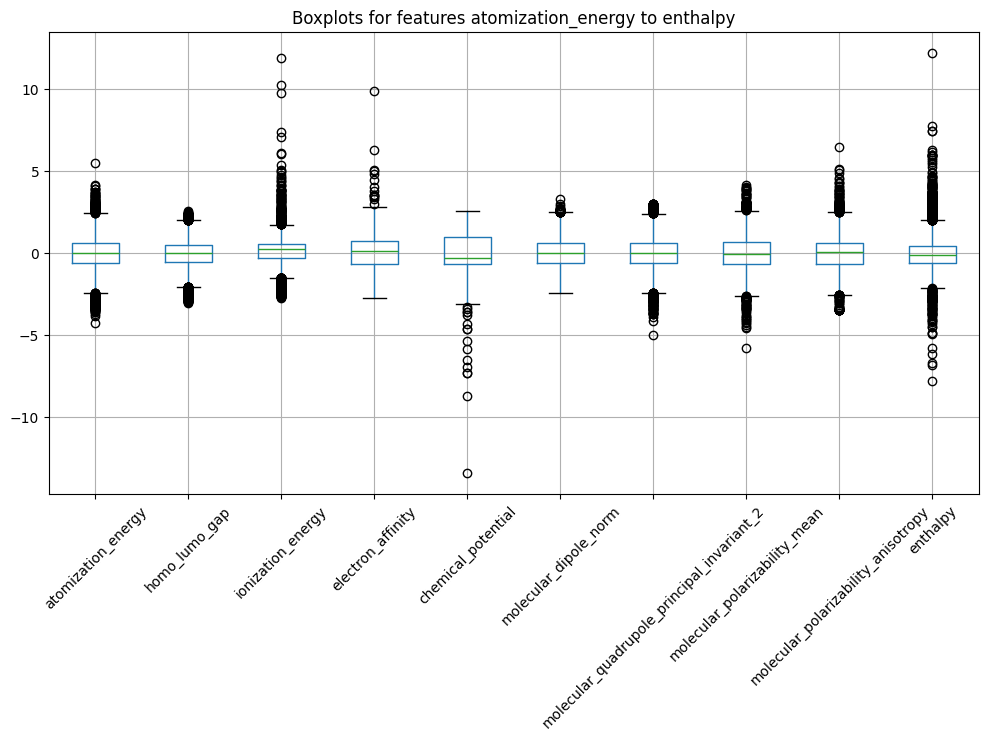

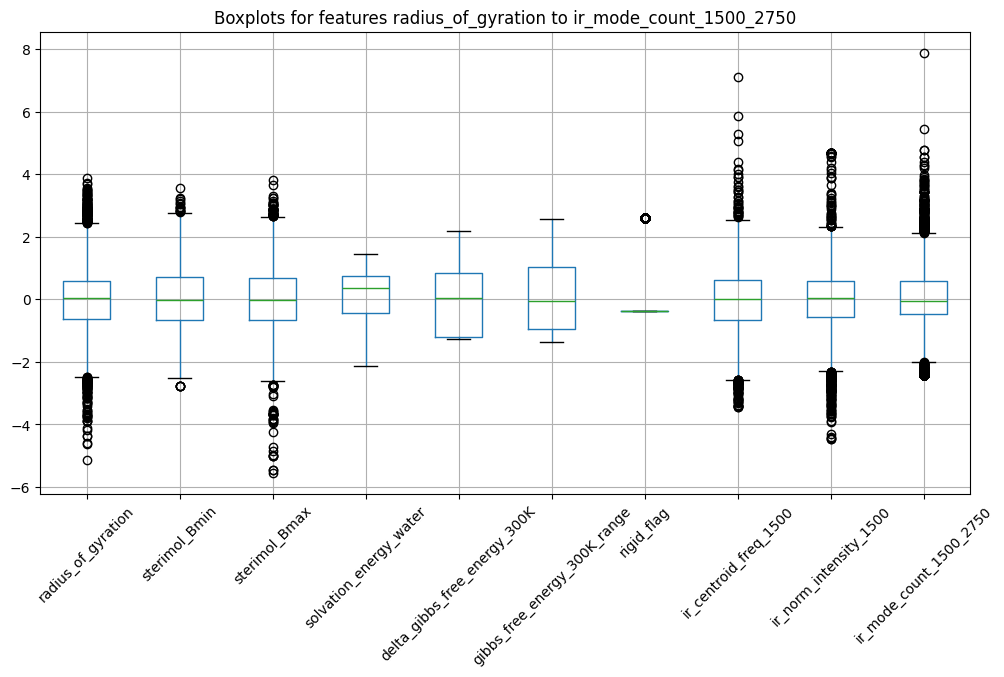

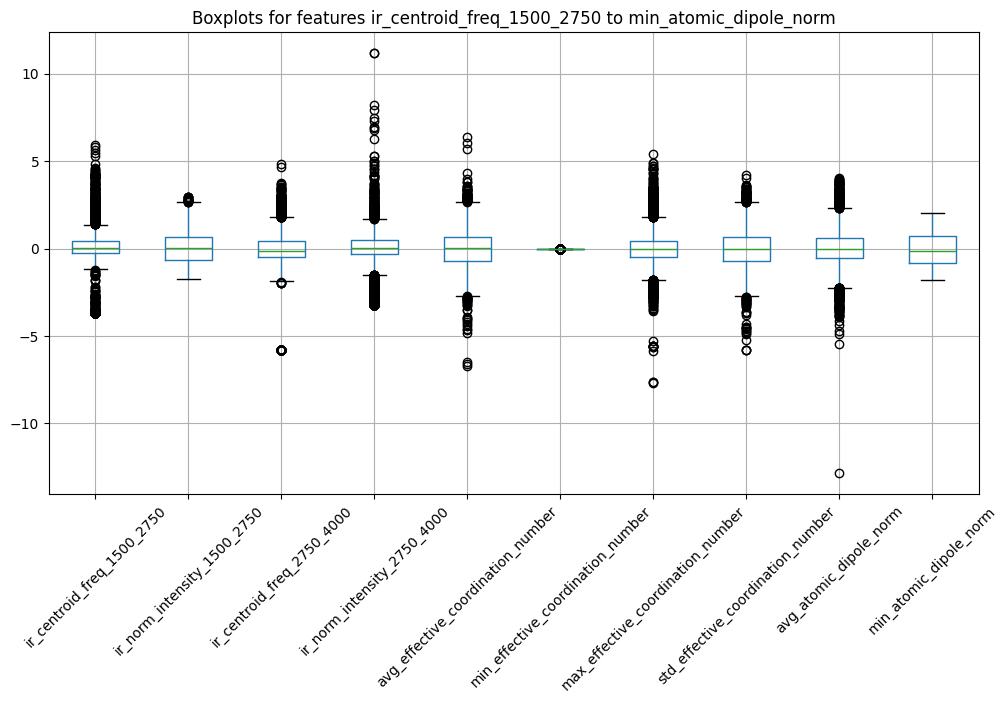

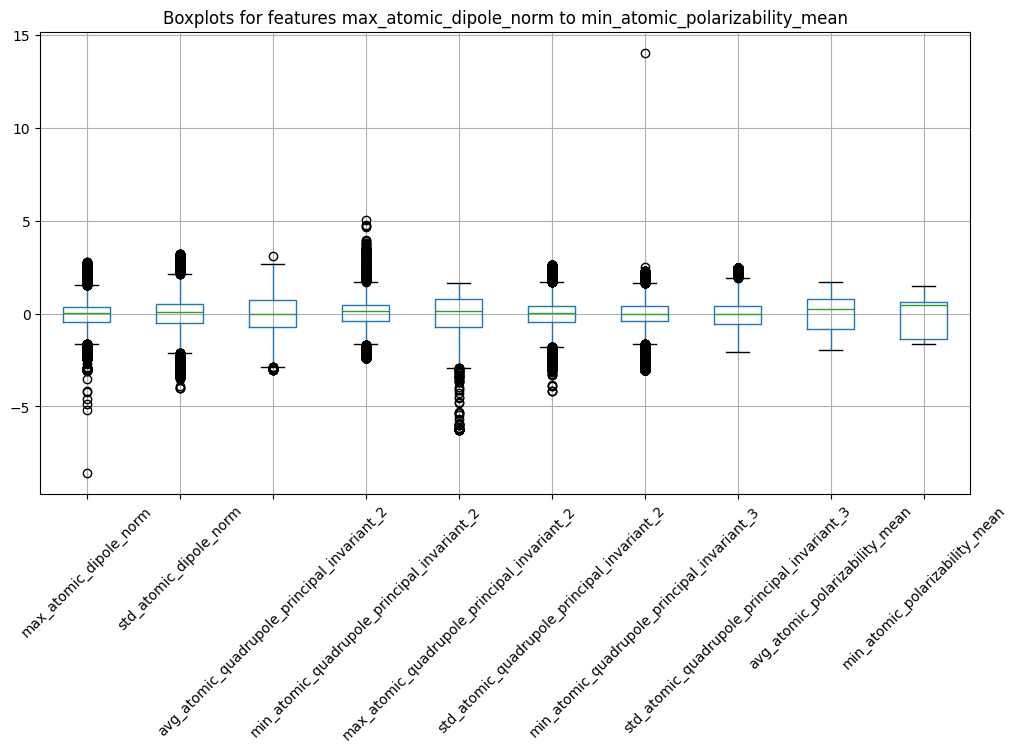

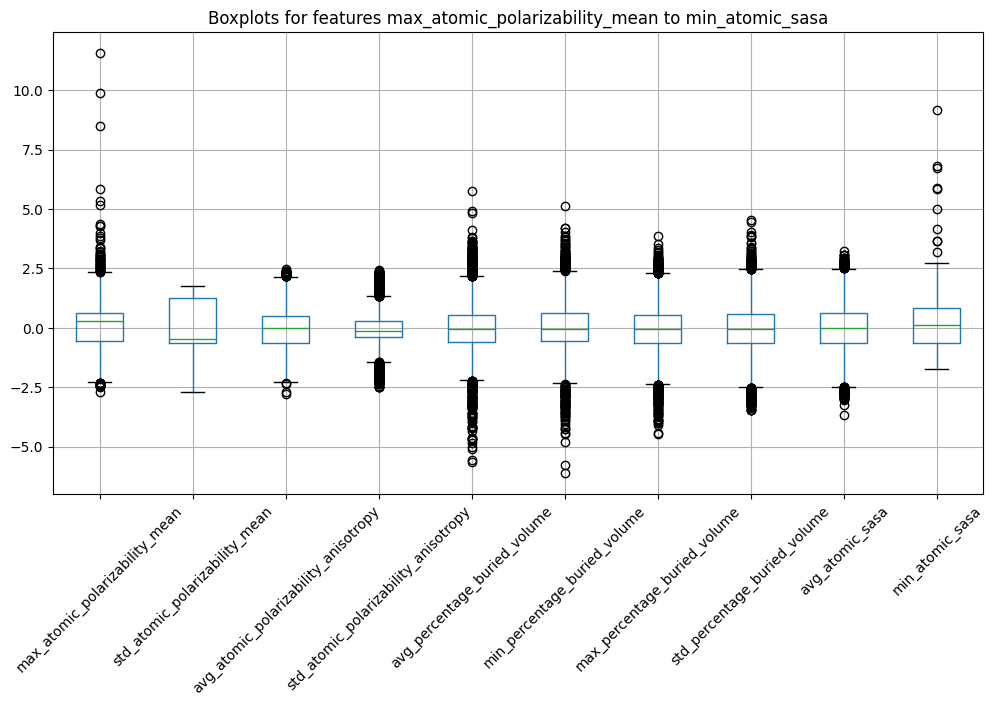

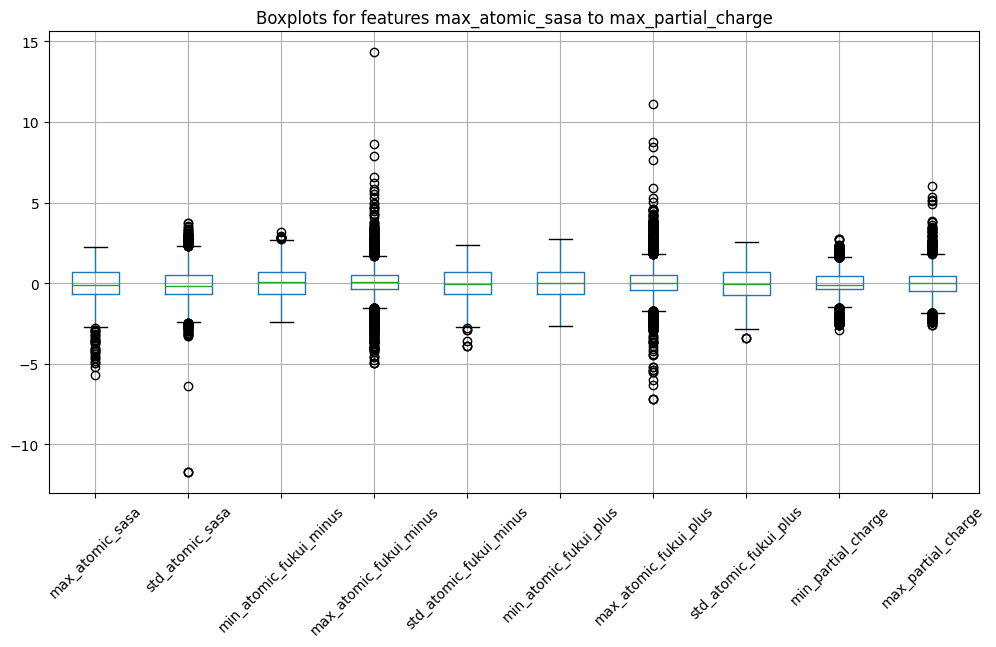

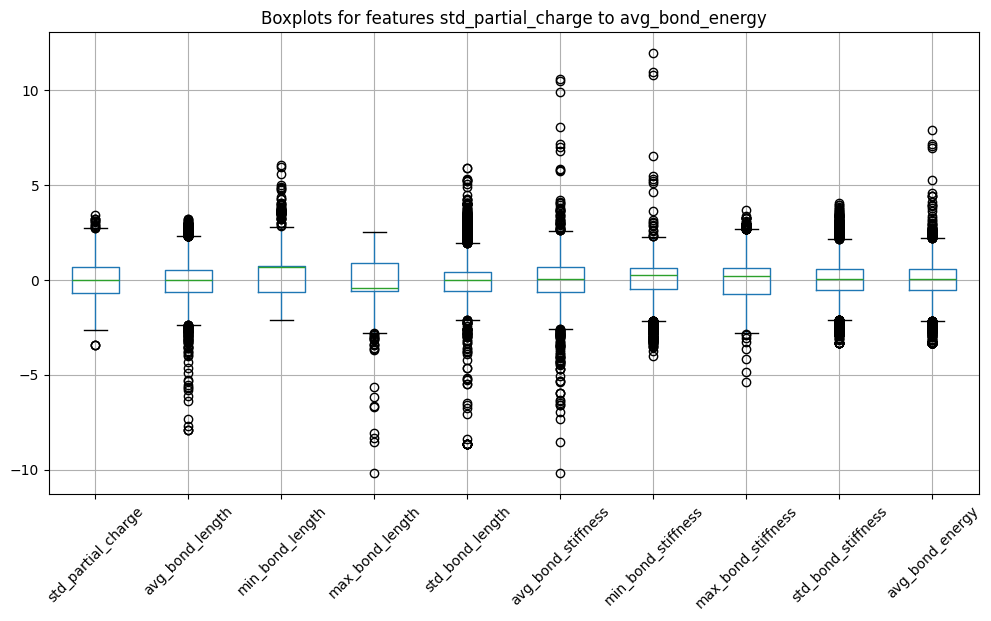

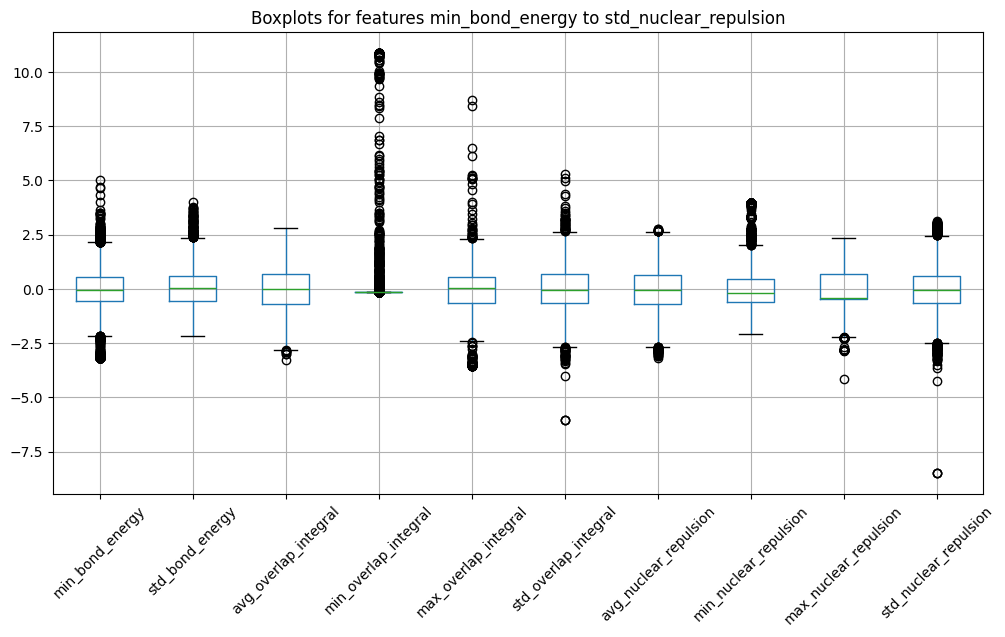

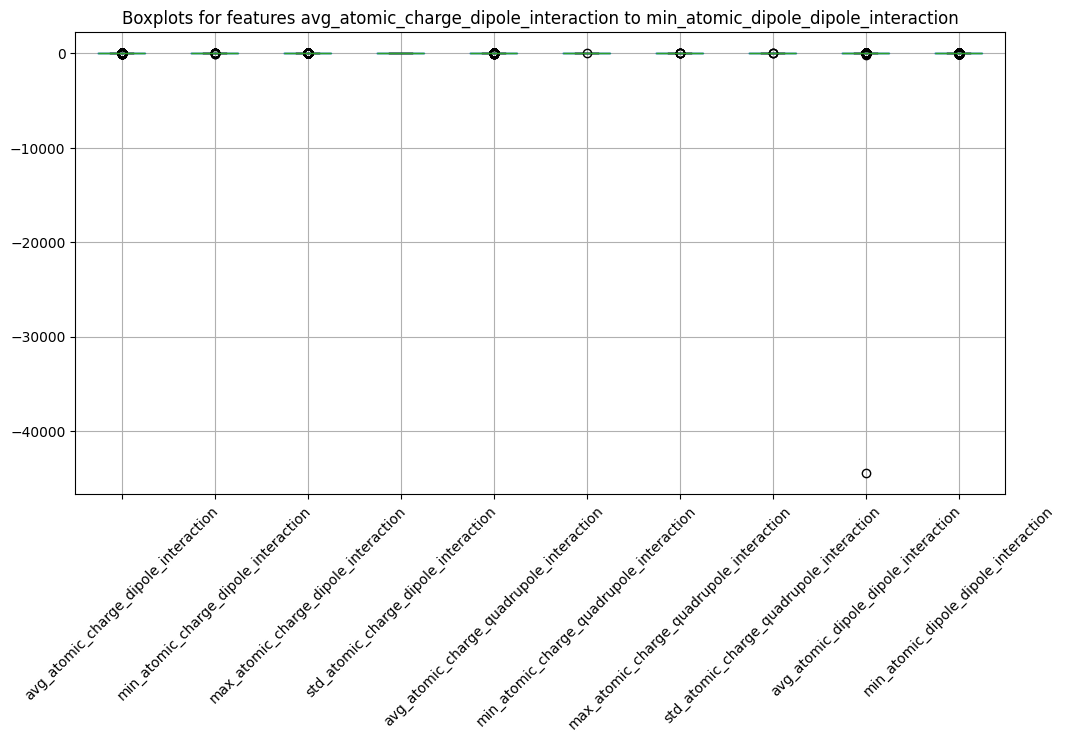

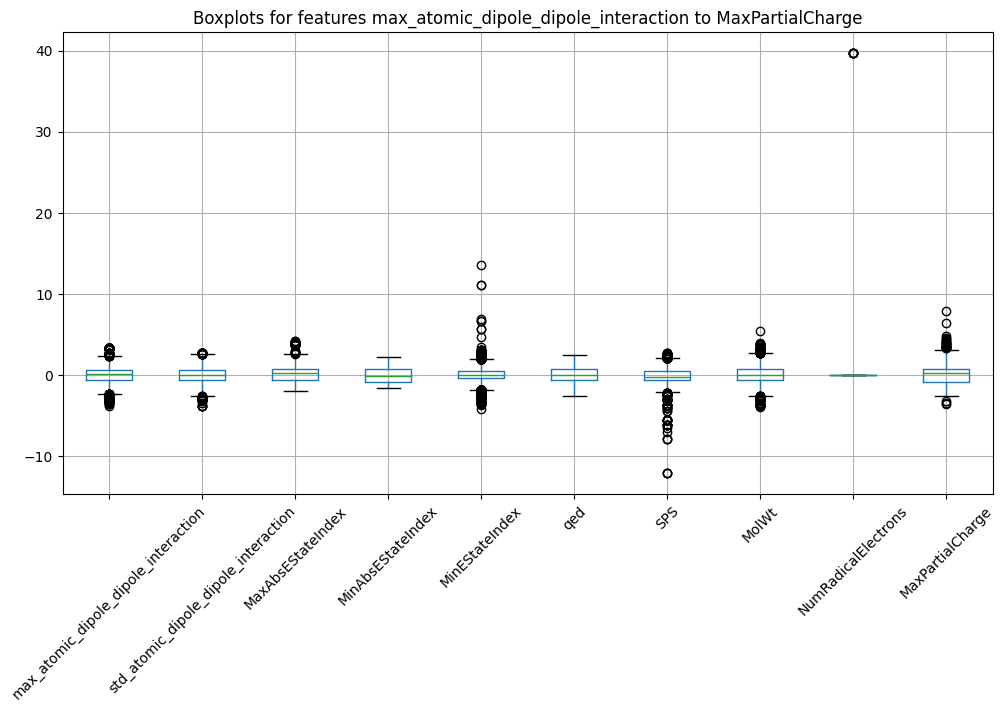

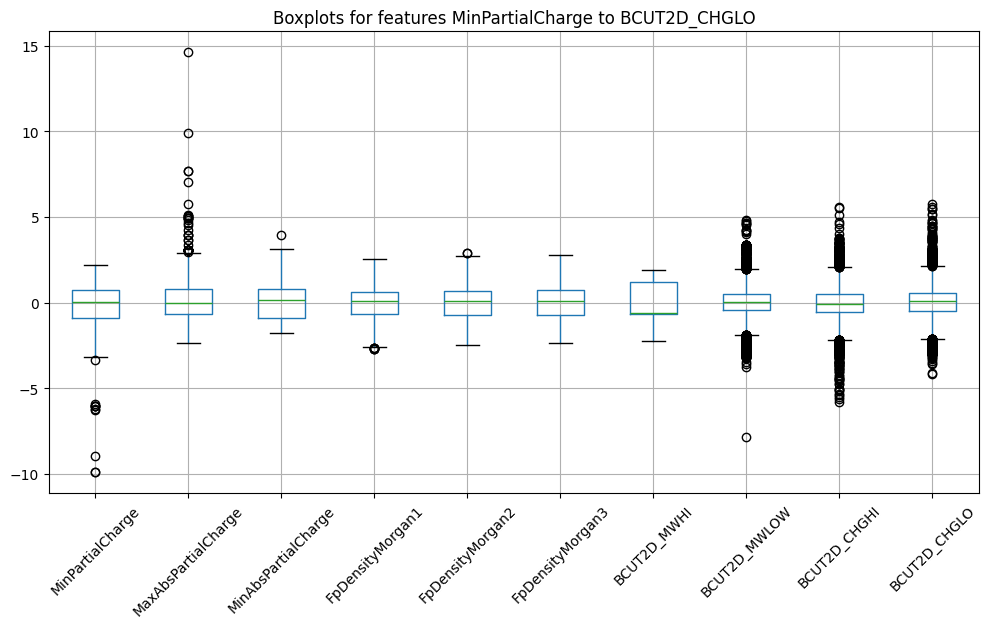

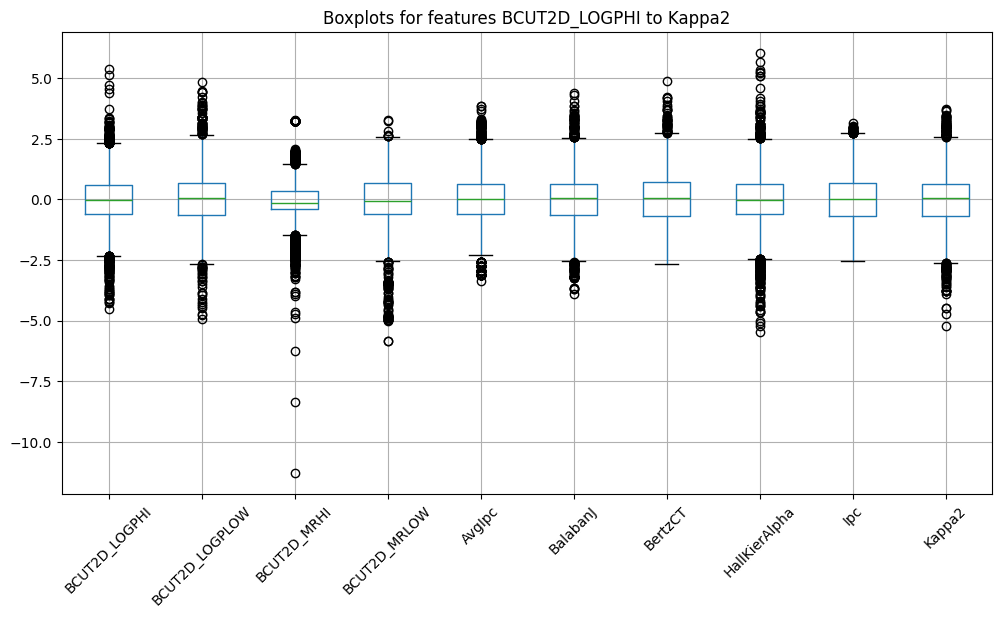

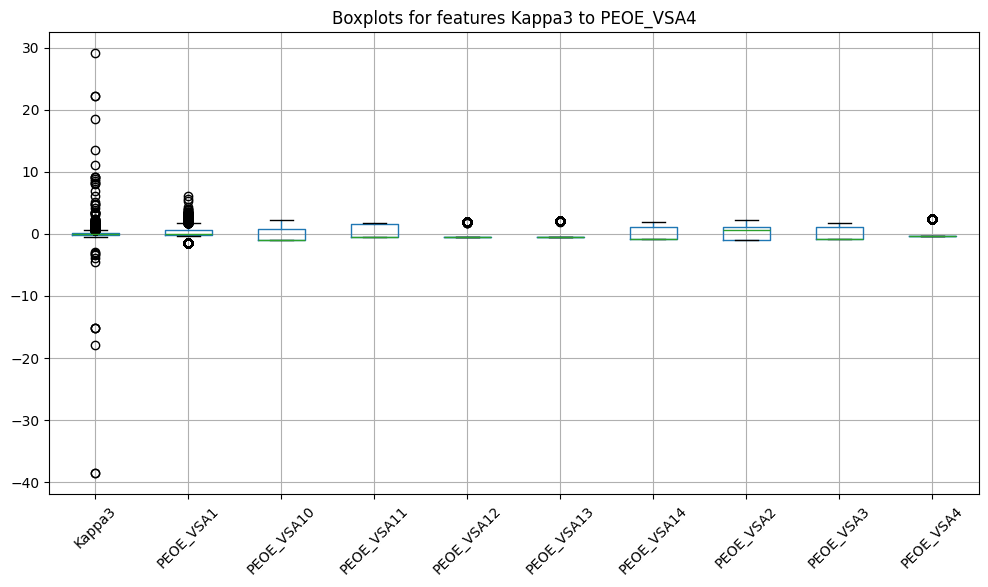

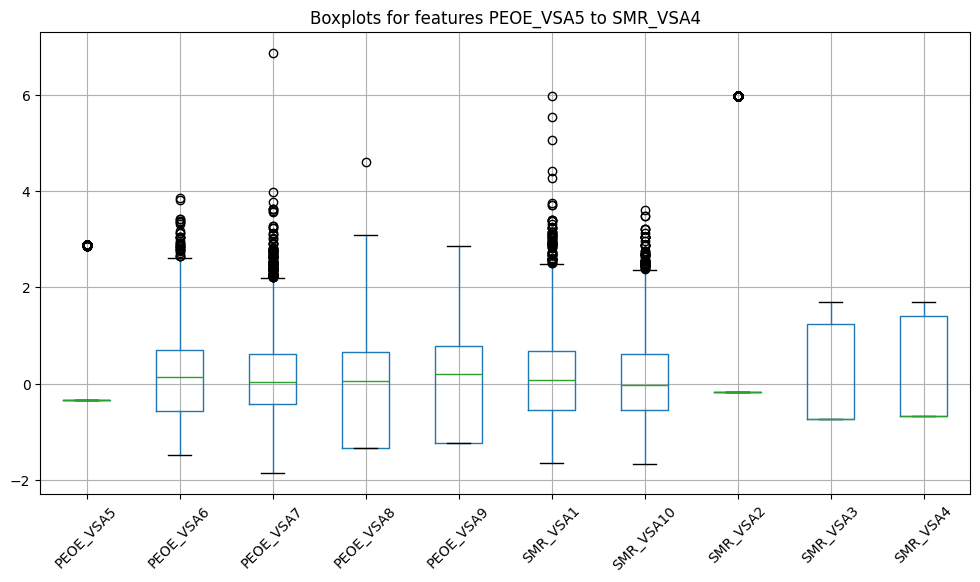

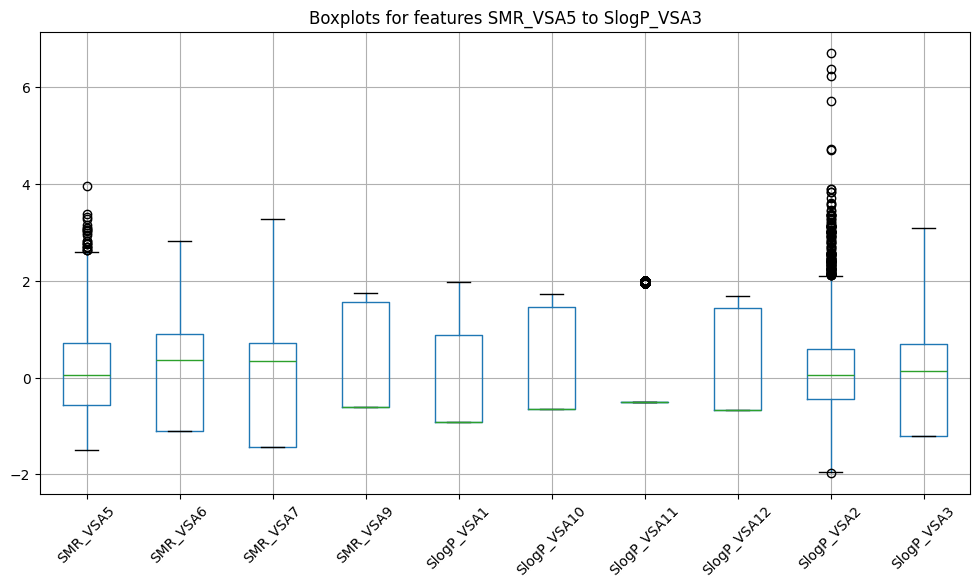

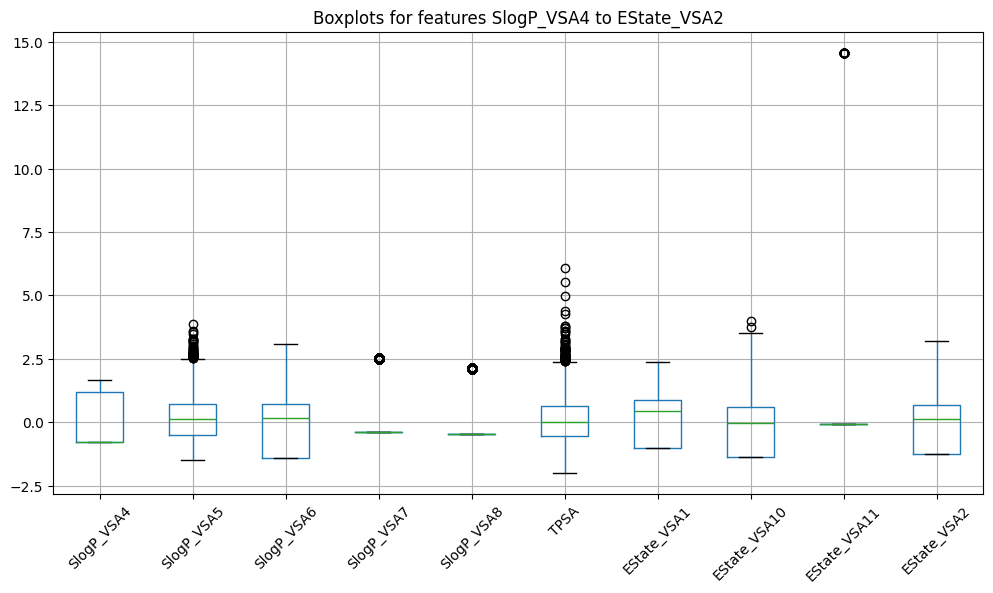

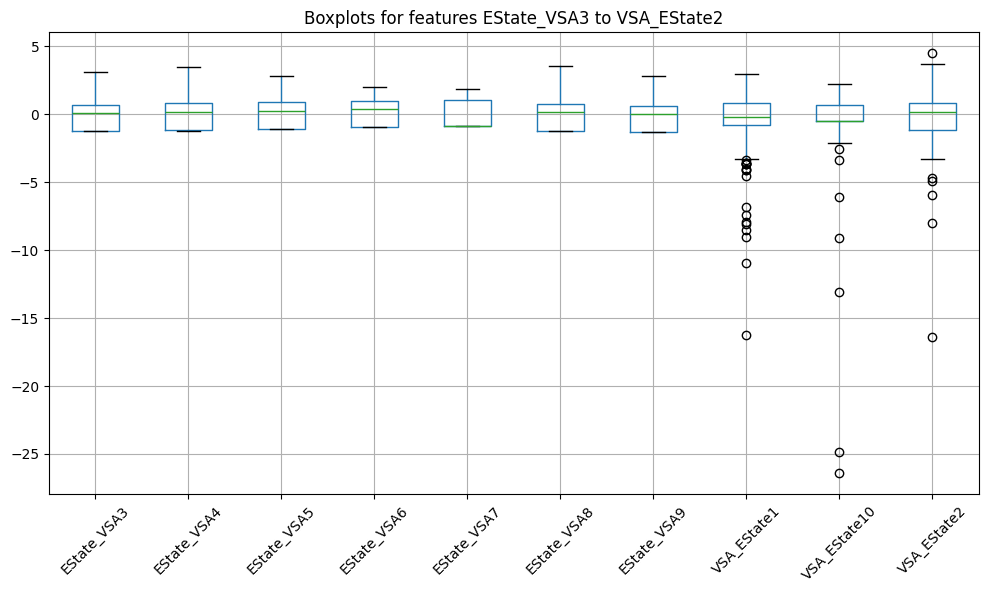

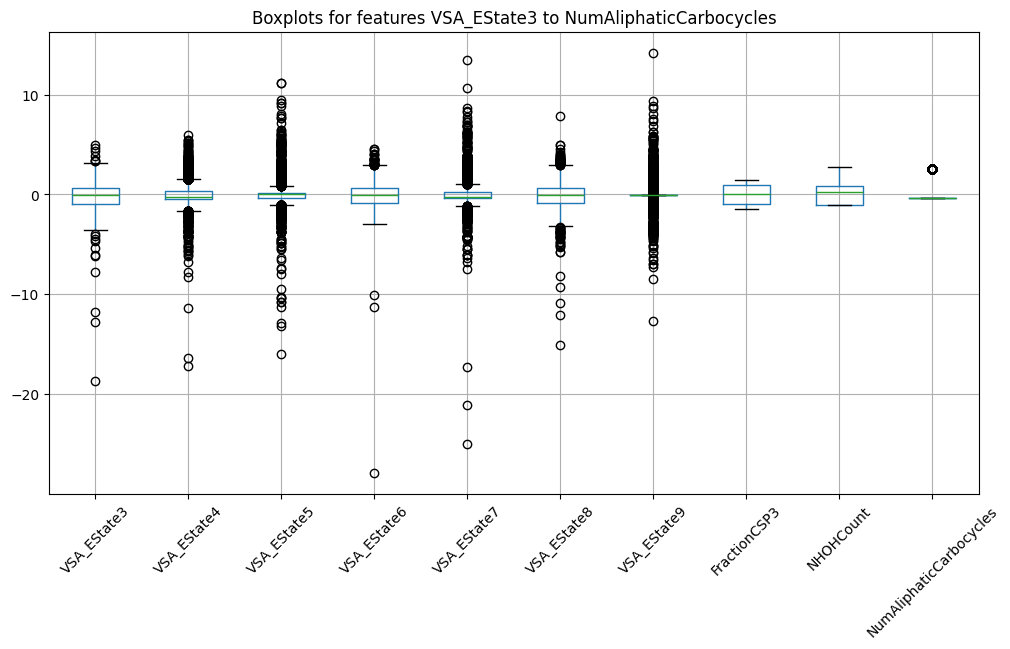

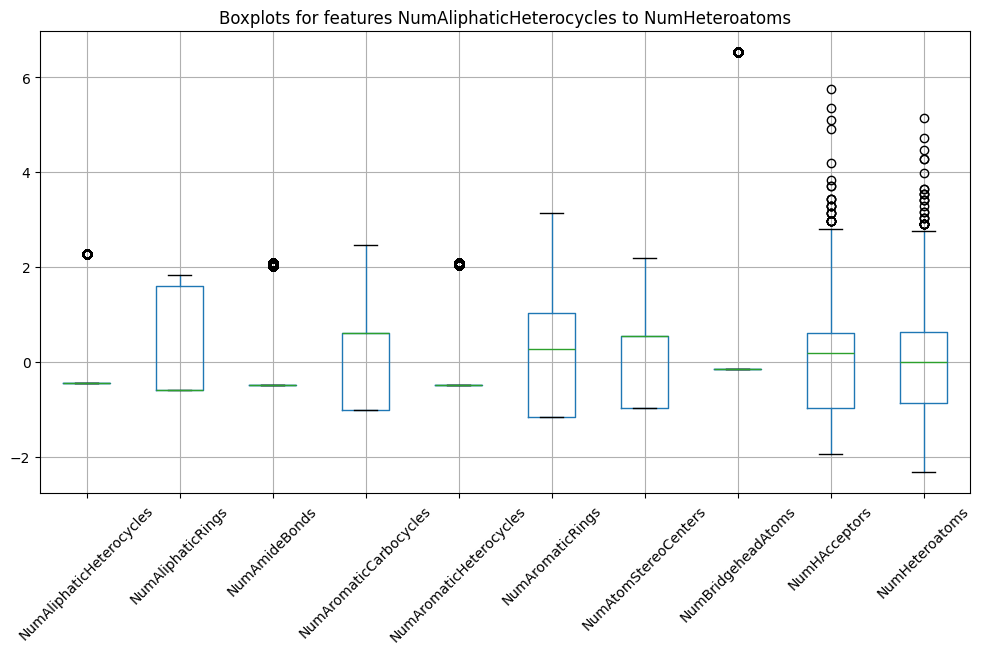

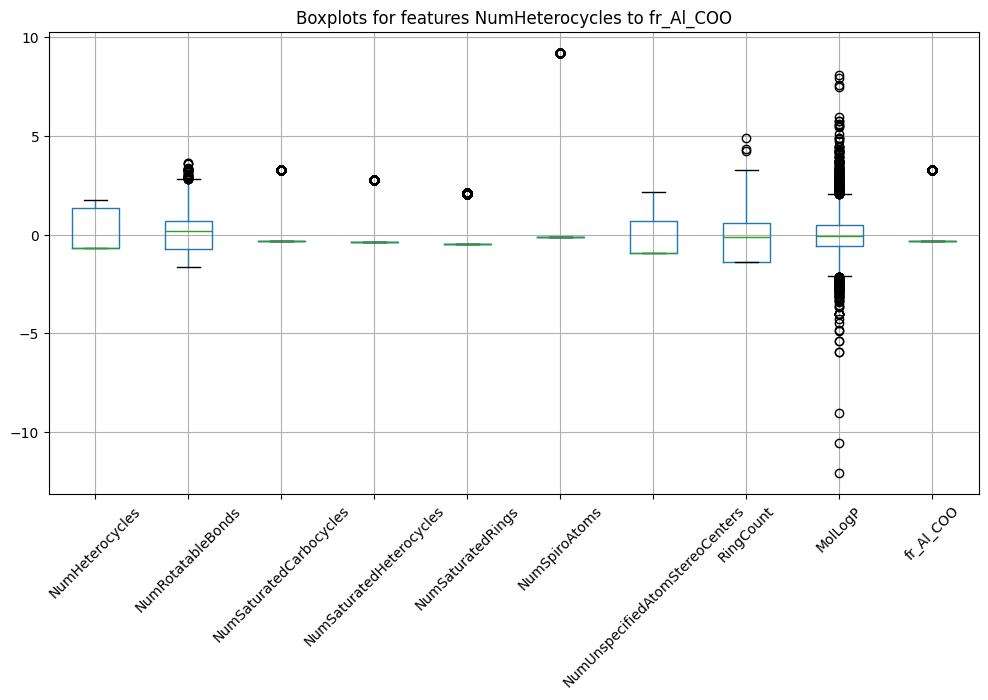

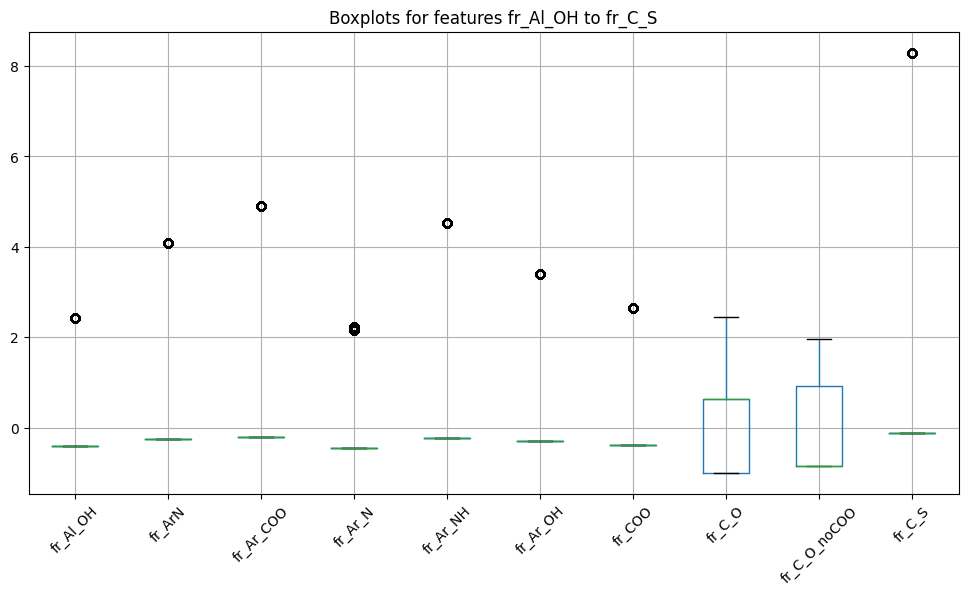

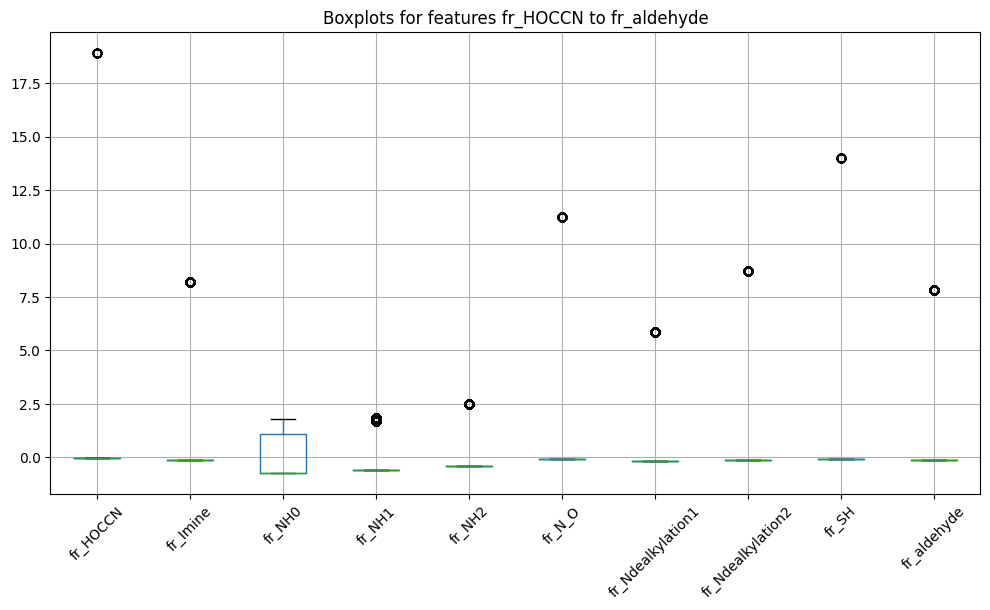

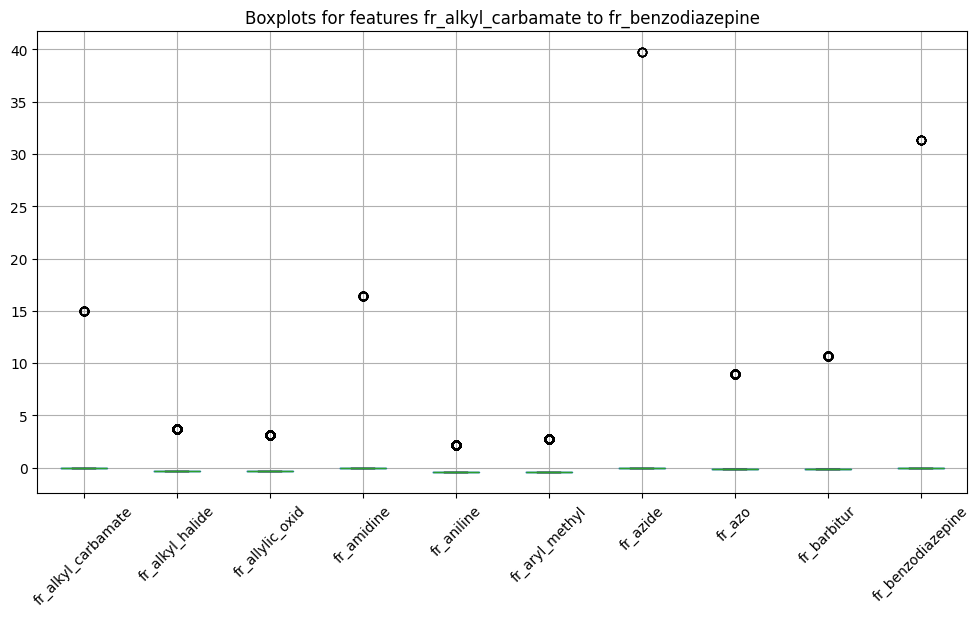

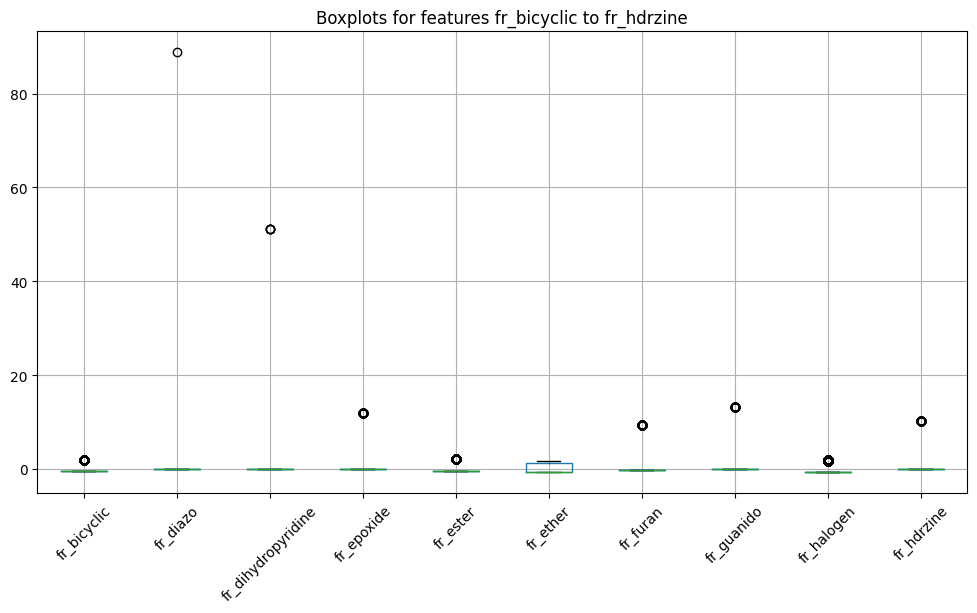

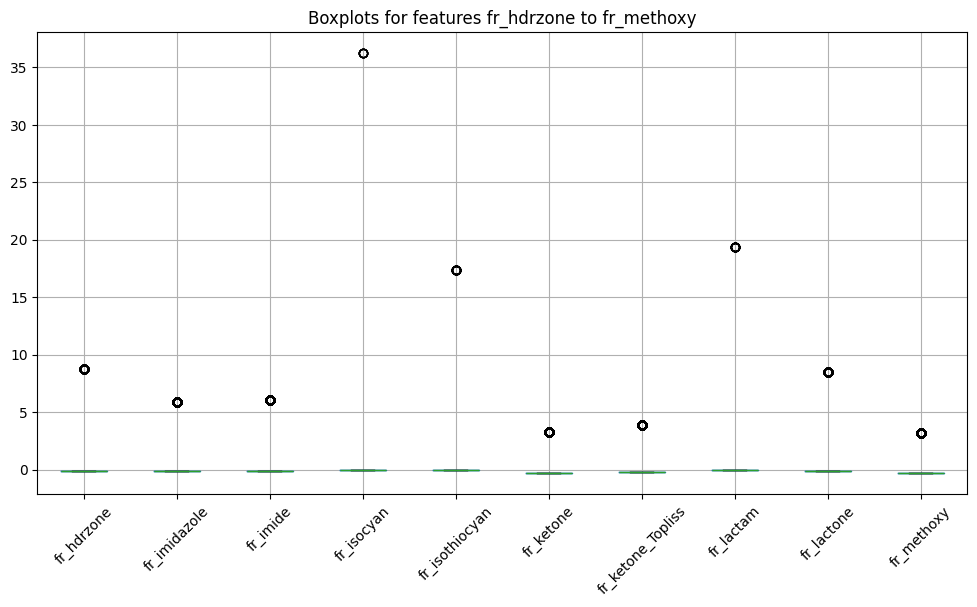

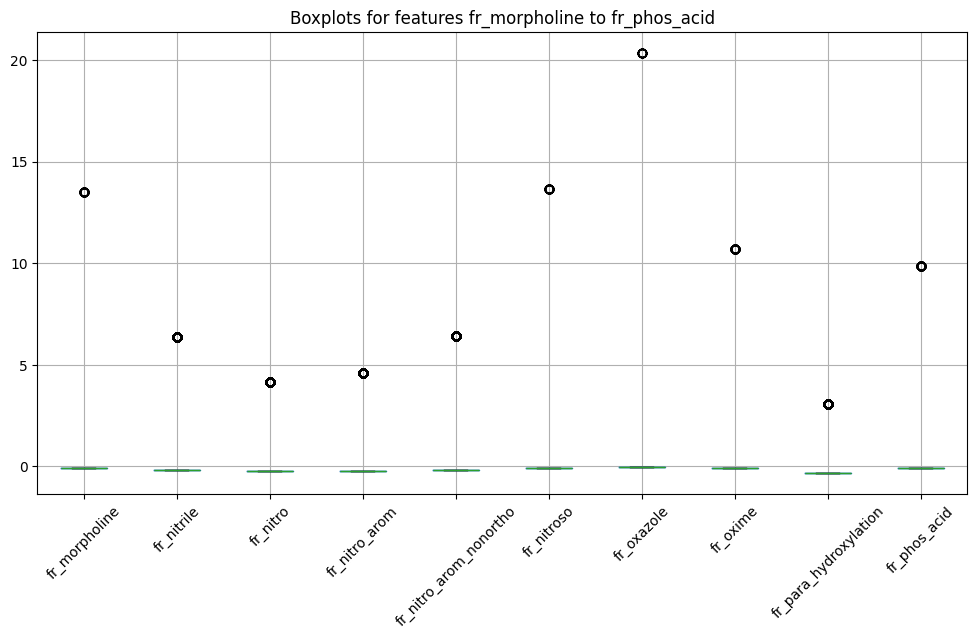

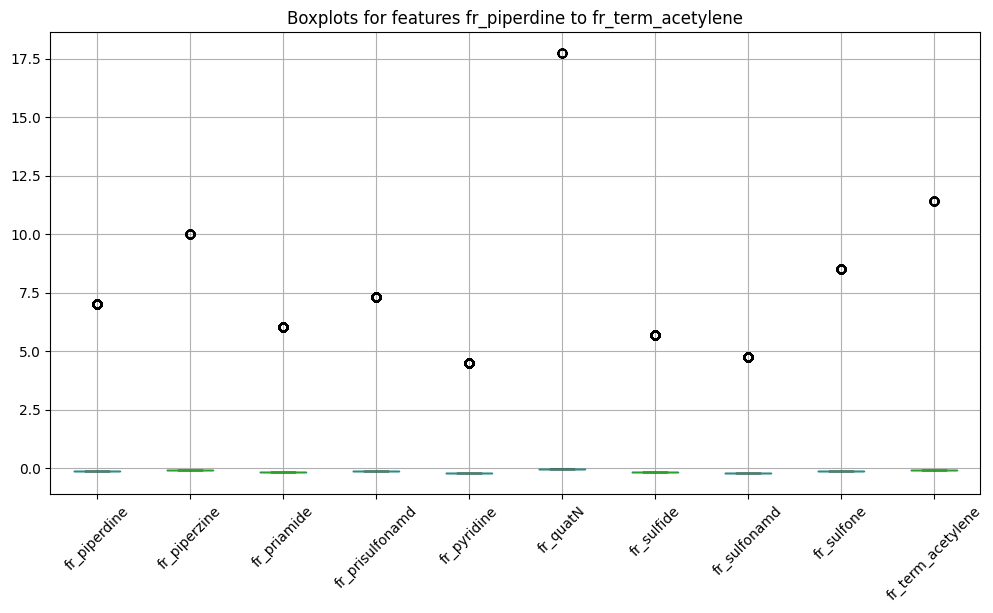

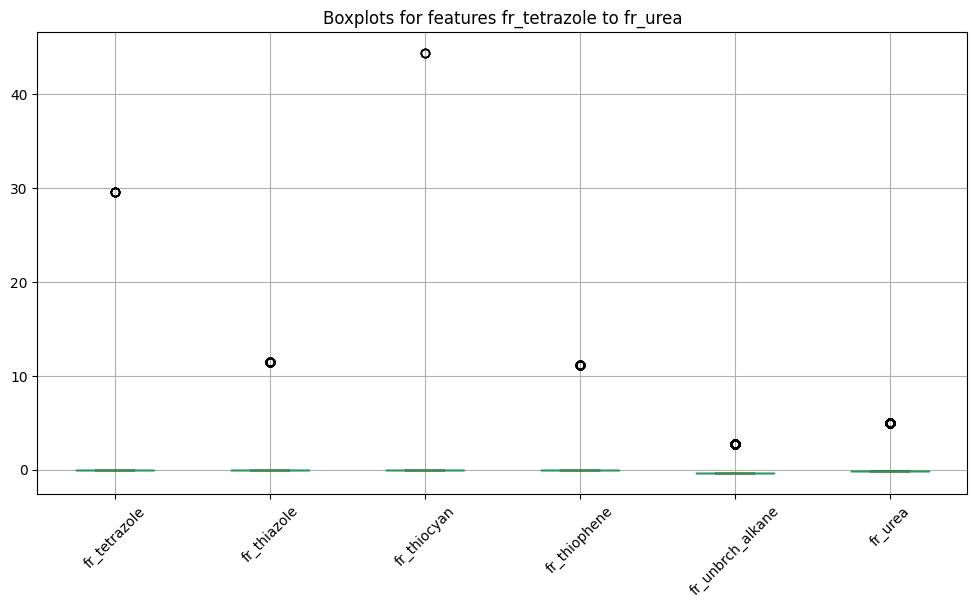

In [132]:
feature_groups = [X_trans_df.columns[i:i+10] for i in range(0, len(X_trans_df.columns), 10)]

for i, group in enumerate(feature_groups, 1):
    plt.figure(figsize=(12,6))
    X_trans_df[group].boxplot()
    plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
    plt.xticks(rotation=45)
    plt.show()

In [135]:
X_trans_df["avg_atomic_dipole_dipole_interaction"].describe()

count     8761.000000
mean        -5.093646
std        475.010459
min     -44460.607740
25%         -0.480510
50%         -0.204470
75%          0.228184
max          7.416258
Name: avg_atomic_dipole_dipole_interaction, dtype: float64

In [143]:
df["avg_atomic_dipole_dipole_interaction"].argmax()
df.iloc[3661]["smiles"]

'[O:1]=[O:2]'

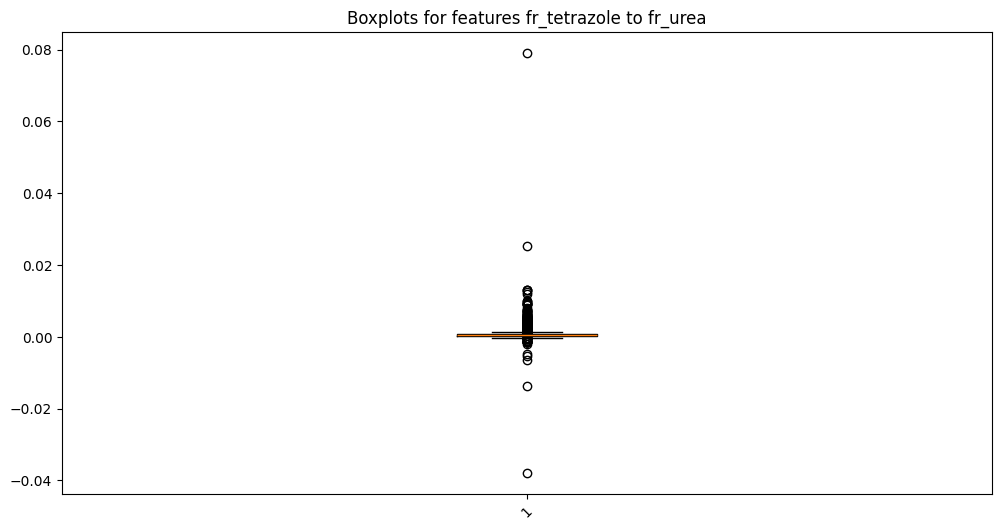

In [141]:
plt.figure(figsize=(12,6))
plt.boxplot(df["avg_atomic_dipole_dipole_interaction"])
plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
plt.xticks(rotation=45)
plt.show()

In [14]:


from scipy.stats import ttest_rel

ttest_result = ttest_rel(scores_combo["test_r2"], scores_topo["test_r2"])
print(f"p-value: {ttest_result[1]} -> not statistically significant")

print("Topo mean R2:", scores_topo["test_r2"].mean())
print("Combined mean R2:", scores_combo["test_r2"].mean())
print("Mean improvement:", (scores_combo["test_r2"] - scores_topo["test_r2"]).mean())

p-value: 0.5621690523329024 -> not statistically significant
Topo mean R2: 0.8173806995189231
Combined mean R2: 0.8215690359567269
Mean improvement: 0.004188336437803764


In [15]:
print(f"Train MSE scores:\nTopology alone: {np.abs(scores_topo["train_MSE"]).mean()}\nQM alone: {np.abs(scores_qm["train_MSE"]).mean()}\nCombined: {np.abs(scores_combo["train_MSE"]).mean()}")
print("\n")
print(f"Test MSE scores:\nTopology alone: {np.abs(scores_topo["test_MSE"]).mean()}\nQM alone: {np.abs(scores_qm["test_MSE"]).mean()}\nCombined: {np.abs(scores_combo["test_MSE"]).mean()}")

Train MSE scores:
Topology alone: 0.9090476273849084
QM alone: 1.1723267387205734
Combined: 0.8059319484767314


Test MSE scores:
Topology alone: 0.9707238587867568
QM alone: 1.2848592555455791
Combined: 0.9485756819551445


In [16]:
ttest_result = ttest_rel(np.abs(scores_combo["test_MSE"]), np.abs(scores_topo["test_MSE"]))

print("Topo mean R2:", np.abs(scores_topo["test_MSE"]).mean())
print("Combined mean R2:", np.abs(scores_combo["test_MSE"]).mean())
print("Mean improvement:", (np.abs(scores_combo["test_MSE"]) - np.abs(scores_topo["test_MSE"])).mean())
print(f"p-value: {ttest_result[1]} -> not statistically significant")

Topo mean R2: 0.9707238587867568
Combined mean R2: 0.9485756819551445
Mean improvement: -0.022148176831612142
p-value: 0.5620810017368761 -> not statistically significant


For the linear regression, the QM descriptors alone seem to give the worst performance out of the three, but **there seems to be no significant difference between the topological descriptors alone and the combined feature set**. This can mean three things, the QM descriptors provide no advantage because:
- due to the larger dataset (desired outcome)
- They are not so useful for solubility predictions
- The linear model cannot benefit from using them (in one way or another) 

## Recursive Feature Elimination

Lets try and make a RFE to see whether the QM descriptors do in fact provide any value to the linear model.

In [17]:
rfe_pipe = make_pipeline(RFECV(LinearRegression(), cv=cv, scoring="r2", n_jobs=4), "rfe")
rfe_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance', ...), ('remove_corr', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,threshold,0.95
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",False
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


In [18]:
filtered_features = rfe_pipe.get_feature_names_out()
X_rfe = X[filtered_features]
X_rfe.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Columns: 231 entries, atomization_energy to fr_unbrch_alkane
dtypes: float64(155), int64(76)
memory usage: 15.4 MB


In these remaining features, I am curious how many QM features are still left. 

In [42]:
with open("../data/properties.json", "r") as f:
    data = json.load(f)

qm_feature_names = [feature["name_of_property"] for feature in data]

In [24]:
scores_pre_rfe = cross_validate(pl_linear, X, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [25]:
scores_post_rfe = cross_validate(pl_linear, X_rfe, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [26]:
train_score_pre_rfe = scores_pre_rfe["train_r2"].mean()
test_score_pre_rfe = scores_pre_rfe["test_r2"].mean()
print(f"Pre-RFE:\nTrain score : {train_score_pre_rfe}\nTest score: {test_score_pre_rfe}\nDifference: {abs(test_score_pre_rfe - train_score_pre_rfe)}")

print("\n")

train_score_rfe = scores_post_rfe['train_r2'].mean()
test_score_rfe = scores_post_rfe['test_r2'].mean()
print(f"Post-RFE:\nTrain score : {train_score_rfe}\nTest score: {test_score_rfe}\nDifference: {abs(test_score_rfe - train_score_rfe)}")

Pre-RFE:
Train score : 0.8486718410870815
Test score: 0.8215690359567269
Difference: 0.027102805130354568


Post-RFE:
Train score : 0.848383203926588
Test score: 0.8229526949889514
Difference: 0.025430508937636542


The difference between the test and train score is for both situations small => no overfitting

In [27]:
print(f"Pre-RFE R2 score: {scores_pre_rfe['test_r2'].mean()}\nPost-RFE R2 score: {scores_post_rfe['test_r2'].mean()}\nMean improvement: {(scores_post_rfe['test_r2'] - scores_pre_rfe['test_r2']).mean()}")
p_value = ttest_rel(scores_pre_rfe['test_r2'], scores_post_rfe['test_r2'])[1]
print(f"p-value: {p_value}")

Pre-RFE R2 score: 0.8215690359567269
Post-RFE R2 score: 0.8229526949889514
Mean improvement: 0.0013836590322244603
p-value: 0.12216066972413299


Despite the fact that the mean improvement of $R^2$ is so small, the increase is statistically significant. By reducing the amount of features with the RFE, we got an increase in performance.

In [28]:
def get_best_pl(fit):
    return fit["estimator"][fit["test_r2"].argmax()]    

In [29]:
best_post_rfe_pl = get_best_pl(scores_post_rfe)
best_pre_rfe_pl = get_best_pl(scores_pre_rfe)

In [30]:
post_rfe_importance.sort_values()

NameError: name 'post_rfe_importance' is not defined

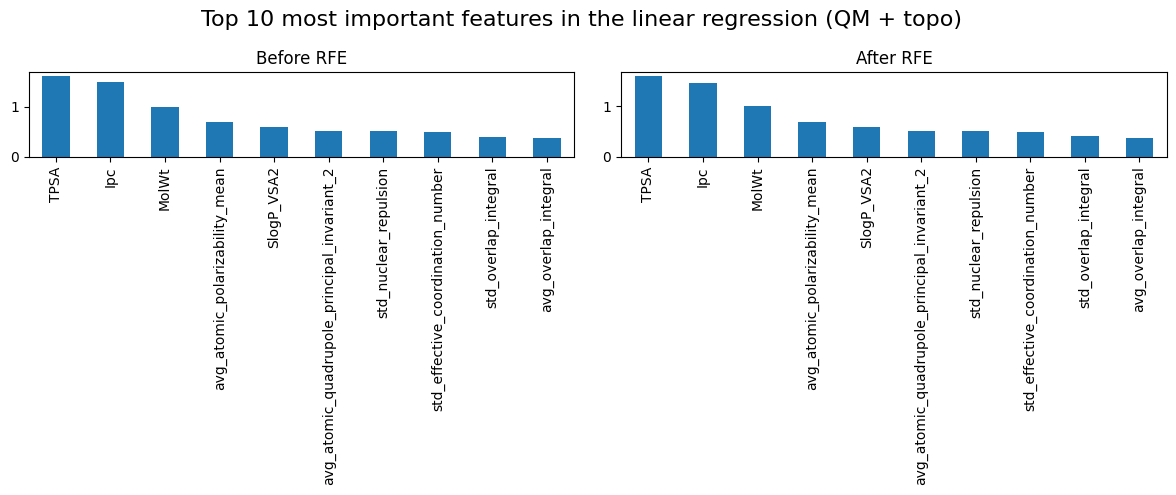

In [35]:
pre_rfe_importance = pd.Series(
    best_pre_rfe_pl.named_steps["predict"].coef_,
    index=best_pre_rfe_pl[:-1].get_feature_names_out()
    )

post_rfe_importance = pd.Series(
    best_post_rfe_pl.named_steps["predict"].coef_,
    index=best_post_rfe_pl[:-1].get_feature_names_out()
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

pre_rfe_importance.abs().sort_values(ascending=False)[:10].plot.bar(ax=ax[0])
ax[0].set_title("Before RFE")

post_rfe_importance.abs().sort_values(ascending=False)[:10].plot.bar(ax=ax[1])
ax[1].set_title("After RFE")

plt.suptitle("Top 10 most important features in the linear regression (QM + topo)", fontsize=16)
plt.tight_layout()
plt.show()

In [32]:
qm_remaining_features = X_rfe.columns[X_rfe.columns.isin(X_qm)]
print(len(qm_remaining_features))
post_rfe_importance[qm_remaining_features].sort_values()

77


avg_atomic_quadrupole_principal_invariant_2   -0.517727
std_overlap_integral                          -0.406521
avg_overlap_integral                          -0.372082
avg_percentage_buried_volume                  -0.314785
ir_mode_count_1500_2750                       -0.300597
                                                 ...   
enthalpy                                       0.319038
avg_bond_length                                0.355033
std_effective_coordination_number              0.493177
std_nuclear_repulsion                          0.503719
avg_atomic_polarizability_mean                 0.686755
Length: 77, dtype: float64

In [33]:
len(qm_remaining_features)

77

In [ ]:
tot_cols = len(X_rfe.columns)
fr_cols = len(X_rfe.filter(regex="fr_").columns)
qm_cols = len(qm_remaining_features)
print(f"Fraction of 'fr_' features remaining in the dataset: {fr_cols / tot_cols}")
print(f"Fraction of QM features remaining in the dataset: {qm_cols / tot_cols}")

Fraction of 'fr_' features remaining in the dataset: 0.28125
Fraction of QM features remaining in the dataset: 0.0625
